# Plot QCL maps with corrections

In [5]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
from matplotlib_scalebar.scalebar import ScaleBar
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import os
from glob import glob
import re
import pathlib

import os, sys
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)

import pySNOM
from pySNOM import readers
from pySNOM import images
from pySNOM.spectra import NeaSpectrum

### Read image

In [36]:
onedrive_folder = glob(os.path.expanduser("~\\OneDrive"))
basefolder = os.path.join(onedrive_folder[0], r"SOLEIL\Projects\Users\Kenneth\Data\RandomNiceMeas")

name = "2024-11-26 161330 PH Li Guiinius Pysdra-Box1-S1-Slice4_Sp2_1377_cm-1"
fname = rf"{name}\{name} O3P raw.gsf"
fpath = os.path.join(basefolder,fname)
data_reader = readers.GsfReader(fpath)
imageO3P = data_reader.read()

fname = rf"{name}\{name} O2P raw.gsf"
fpath = os.path.join(basefolder,fname)
data_reader = readers.GsfReader(fpath)
imageO2P = data_reader.read()


## Corrections

In [41]:
sr = images.SelfReference(referencedata=imageO2P.data,datatype=images.DataTypes.Phase)
d = sr.transform(imageO3P.data)

lowlimit = -.5
highlimit = 0.3
spr = images.RemoveSpikes(threshold=lowlimit, method='median', absolute_threshold=True)
d = spr.transform(d)
spr = images.RemoveSpikes(threshold=highlimit, method='median', higher=True, absolute_threshold=True)
d = spr.transform(d)

sn = images.SimpleNormalize(method='manual',value=-0.2)
d = sn.transform(d)

## Plotting

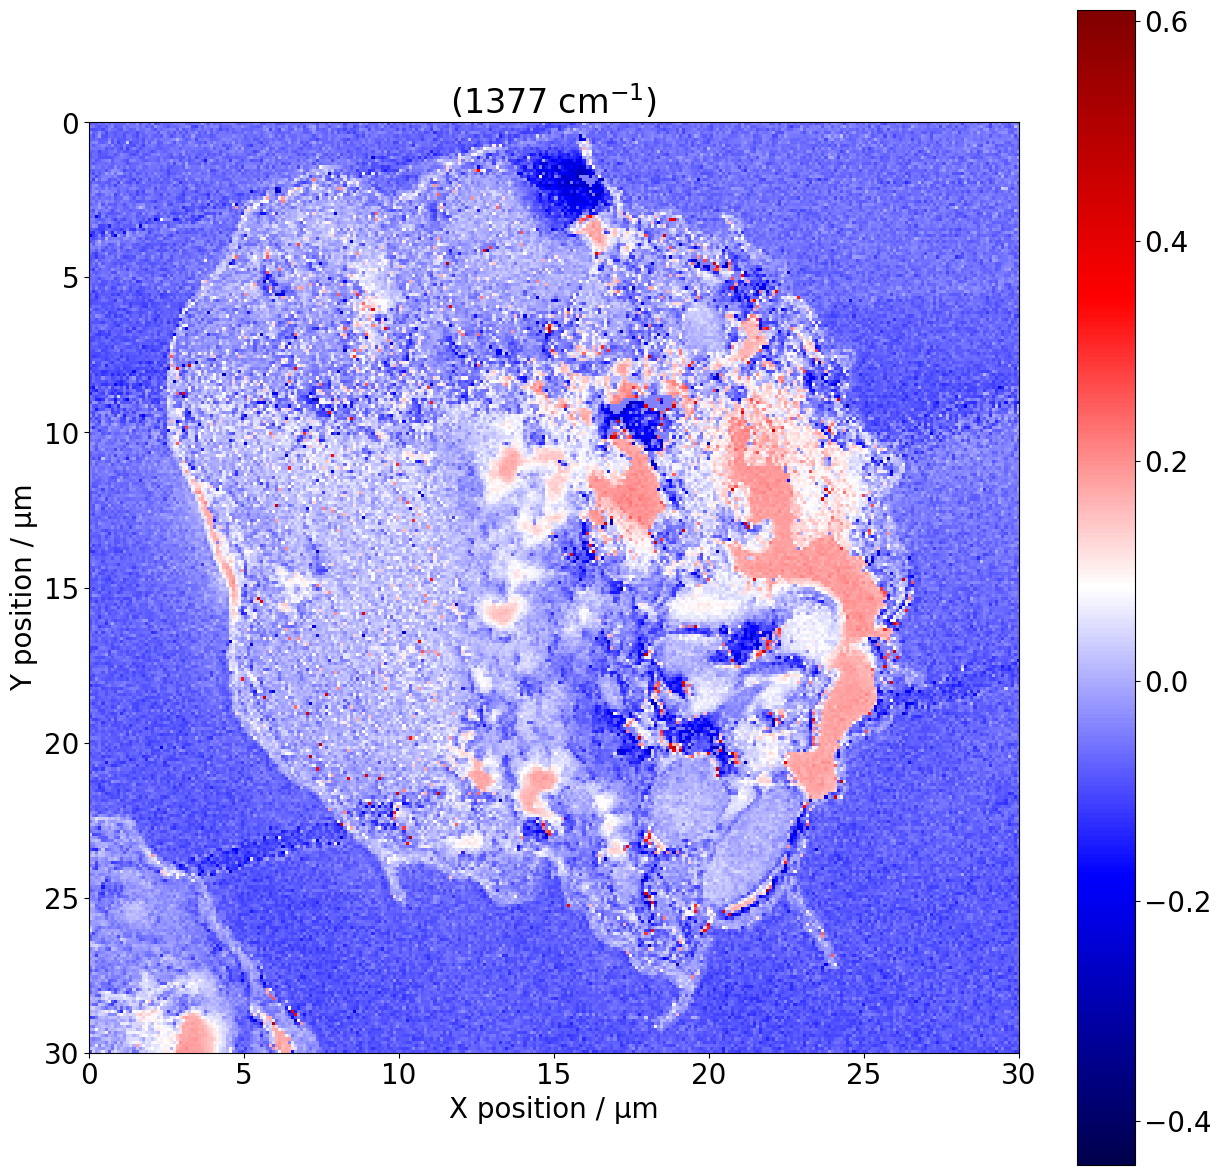

In [43]:
plt.rcParams.update({'font.size': 20})
# Plot image
xmin = (0)*1e6
xmax = (imageO3P.xreal)*1e6
ymin = (imageO3P.yreal)*1e6
ymax = (0)*1e6

px = 1/plt.rcParams['figure.dpi']
fig= plt.figure(figsize=(1500*px, 1500*px))

plt.imshow(d, extent=[xmin, xmax, ymin, ymax], cmap=mpl.colormaps['seismic'], vmin=0.61, vmax=-0.4)
plt.xlabel('X position / μm')
plt.ylabel('Y position / μm')
plt.title('(1377 cm$^{-1}$)')
plt.colorbar()
plt.show()